In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

In [6]:
df = pd.read_csv(r"C:\Users\HP\Downloads\train.csv")
print(f"Dataset Shape: {df.shape}")

df.head()

Dataset Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [7]:
print(df['SalePrice'].describe())

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("\nTop Missing Value Features:")
print(missing.head(10))

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Top Missing Value Features:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_7116\1528210382.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, ax=axes[2], palette='Blues_r')


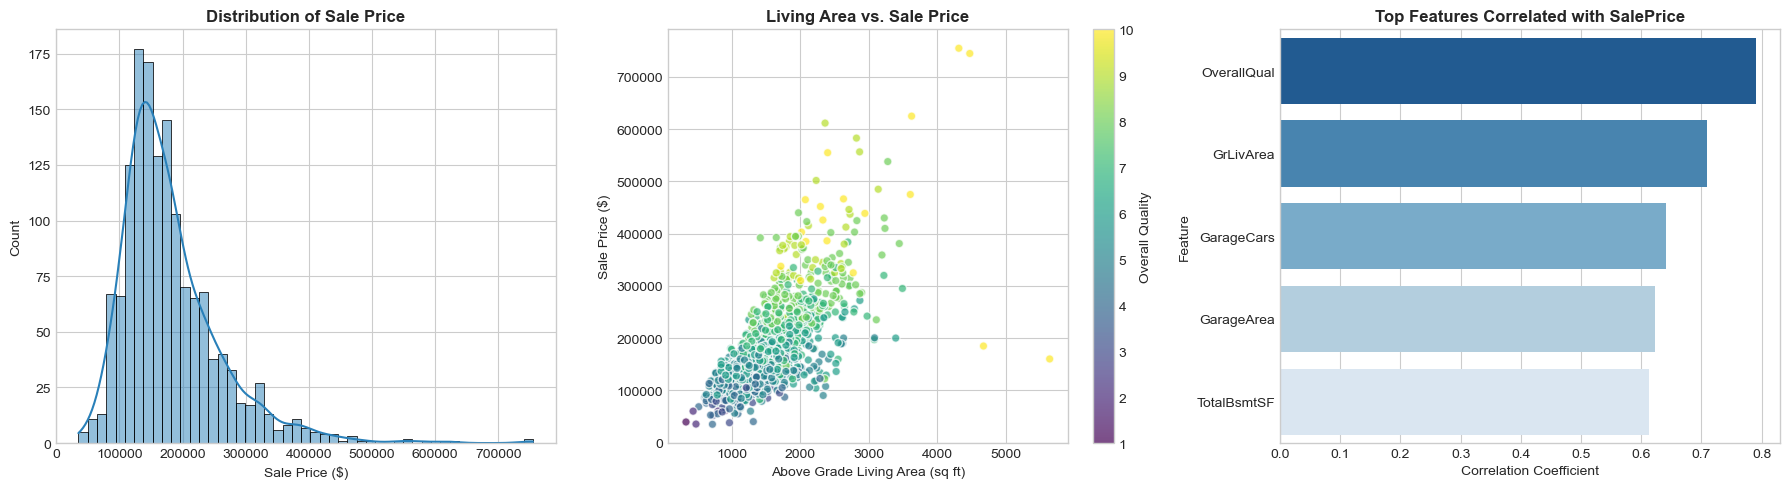

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['SalePrice'], kde=True, ax=axes[0], color='#2980b9')
axes[0].set_title('Distribution of Sale Price', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Count')

scatter = axes[1].scatter(df['GrLivArea'], df['SalePrice'], c=df['OverallQual'], cmap='viridis', alpha=0.7, edgecolor='w')
axes[1].set_title('Living Area vs. Sale Price', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Above Grade Living Area (sq ft)')
axes[1].set_ylabel('Sale Price ($)')
fig.colorbar(scatter, ax=axes[1], label='Overall Quality')

numeric_df = df.select_dtypes(include=[float, int])
correlations = numeric_df.corr()['SalePrice'].sort_values(ascending=False)
top_corr = correlations.iloc[1:6]
sns.barplot(x=top_corr.values, y=top_corr.index, ax=axes[2], palette='Blues_r')
axes[2].set_title('Top Features Correlated with SalePrice', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Correlation Coefficient')
axes[2].set_ylabel('Feature')

plt.tight_layout()
plt.show()